# Problema 3  
## TSP como problema de búsqueda



## 1. Formulación como problema de búsqueda

En el problema del viajero se tiene un conjunto de ciudades y una distancia entre cada par de ellas.

El objetivo es:

1. iniciar en una ciudad,
2. visitar cada ciudad una sola vez,
3. regresar a la ciudad de inicio,
4. y lograr que la distancia total sea la menor posible.

### Espacio de configuraciones

Las posibles soluciones son todas las rutas que empiezan en una ciudad, pasan por todas las demás una sola vez y al final regresan al punto de inicio.

En otras palabras, cada configuración representa un posible recorrido completo entre las ciudades.

También pueden existir configuraciones parciales, es decir, rutas que todavía no incluyen todas las ciudades, pero que ya muestran parte del recorrido.

### Tamaño del espacio de búsqueda

La cantidad de rutas posibles depende del número de ciudades.

Mientras más ciudades haya, más grande será el número de posibles recorridos.

### Descripción de las configuraciones

Cada configuración puede representarse como un orden en el que se visitan las ciudades.

Durante la búsqueda, también se puede trabajar con rutas parciales, agregando una ciudad nueva en cada paso sin repetir las anteriores.

### Función de costo

El costo de una solución se obtiene sumando todas las distancias recorridas, incluyendo el regreso a la ciudad inicial.

### Objetivo

El objetivo es encontrar la ruta con la menor distancia total posible.

### Componentes de búsqueda

- **Estado inicial:** ciudad de inicio.
- **Acción:** agregar una ciudad que no haya sido visitada.
- **Restricción:** no repetir ciudades.
- **Meta:** visitar todas las ciudades y regresar al punto de partida.

In [1]:
import itertools
import networkx as nx
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (8, 5)

## 2. Grafo completo pequeño de ejemplo

Usaremos 4 ciudades para que el árbol de búsqueda se pueda visualizar fácilmente.

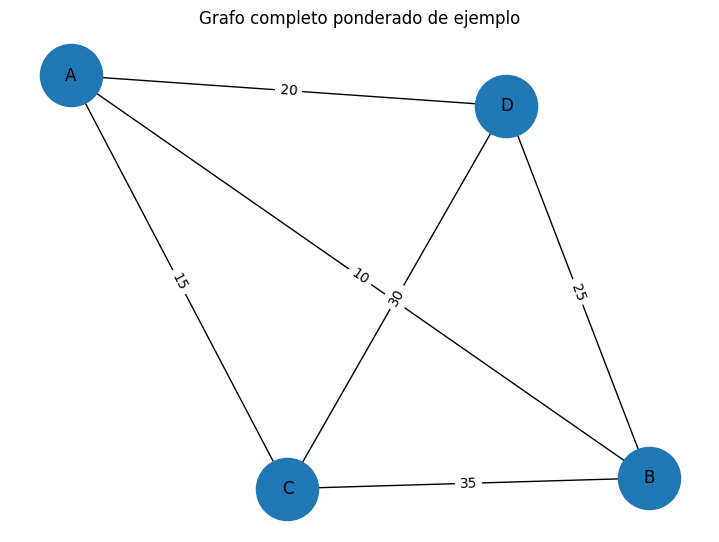

In [2]:
cities = ["A", "B", "C", "D"]

weights = {
    ("A", "B"): 10,
    ("A", "C"): 15,
    ("A", "D"): 20,
    ("B", "C"): 35,
    ("B", "D"): 25,
    ("C", "D"): 30,
}

def dist(u, v):
    if u == v:
        return 0
    key = tuple(sorted((u, v)))
    return weights[key]

G = nx.Graph()
for (u, v), w in weights.items():
    G.add_edge(u, v, weight=w)

pos = nx.spring_layout(G, seed=9)

plt.figure(figsize=(7, 5))
nx.draw(G, pos, with_labels=True, node_size=2000)
nx.draw_networkx_edge_labels(G, pos, edge_labels=weights)
plt.title("Grafo completo ponderado de ejemplo")
plt.axis("off")
plt.show()

## 3. Árbol de búsqueda
Se fijará la ciudad inicial como **A**.

Entonces:

- la raíz es `['A']`,
- en el nivel 1 se elige la segunda ciudad,
- en el nivel 2 se elige la tercera ciudad,
- en el nivel 3 se elige la cuarta ciudad.

Después de eso, solo faltaría regresar a `A` para cerrar el ciclo.

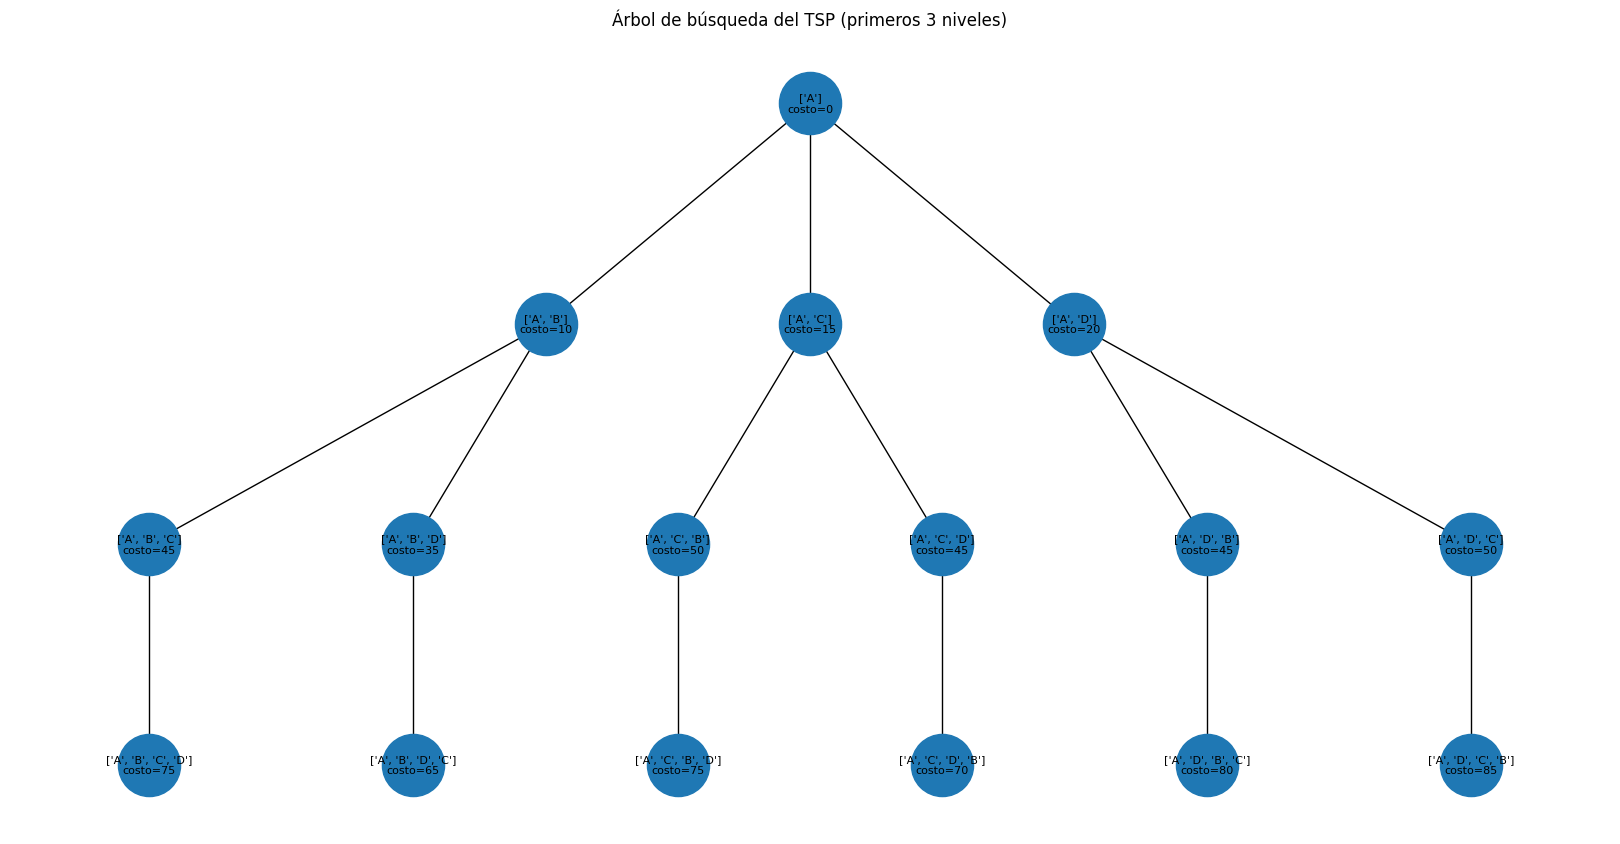

In [3]:
def partial_cost(route):
    return sum(dist(route[i], route[i + 1]) for i in range(len(route) - 1))

def build_tsp_search_tree(cities, start="A", max_depth=3):
    T = nx.DiGraph()
    root = (start,)
    T.add_node(root, level=0, label=f"{list(root)}\ncosto=0")

    def expand(route):
        level = len(route) - 1
        if level == max_depth:
            return

        remaining = [c for c in cities if c not in route]
        for c in remaining:
            new_route = tuple(list(route) + [c])
            T.add_node(
                new_route,
                level=len(new_route) - 1,
                label=f"{list(new_route)}\ncosto={partial_cost(new_route)}",
            )
            T.add_edge(route, new_route)
            expand(new_route)

    expand(root)
    return T

search_tree = build_tsp_search_tree(cities, start="A", max_depth=3)

def layered_positions(G):
    levels = {}
    for node, data in G.nodes(data=True):
        lvl = data["level"]
        levels.setdefault(lvl, []).append(node)

    pos = {}
    for lvl, nodes in levels.items():
        width = len(nodes)
        for i, node in enumerate(nodes):
            x = i - (width - 1) / 2
            y = -lvl
            pos[node] = (x, y)
    return pos

pos_tree = layered_positions(search_tree)
labels_tree = nx.get_node_attributes(search_tree, "label")

plt.figure(figsize=(16, 8))
nx.draw(search_tree, pos_tree, with_labels=False, node_size=2000, arrows=False)
nx.draw_networkx_labels(search_tree, pos_tree, labels=labels_tree, font_size=8)
plt.title("Árbol de búsqueda del TSP (primeros 3 niveles)")
plt.axis("off")
plt.show()

## 4. Búsqueda por fuerza bruta en el ejemplo

Para un número pequeño de ciudades se puede revisar todas las rutas posibles y escoger la de menor costo.

In [4]:
start = "A"
other_cities = [c for c in cities if c != start]

best_route = None
best_cost = float("inf")

print("Rutas posibles desde A:\n")
for perm in itertools.permutations(other_cities):
    route = (start,) + perm + (start,)
    cost = sum(dist(route[i], route[i + 1]) for i in range(len(route) - 1))
    print(route, "-> costo =", cost)

    if cost < best_cost:
        best_cost = cost
        best_route = route

print("\nMejor ruta encontrada:")
print(best_route)
print("Costo mínimo =", best_cost)

Rutas posibles desde A:

('A', 'B', 'C', 'D', 'A') -> costo = 95
('A', 'B', 'D', 'C', 'A') -> costo = 80
('A', 'C', 'B', 'D', 'A') -> costo = 95
('A', 'C', 'D', 'B', 'A') -> costo = 80
('A', 'D', 'B', 'C', 'A') -> costo = 95
('A', 'D', 'C', 'B', 'A') -> costo = 95

Mejor ruta encontrada:
('A', 'B', 'D', 'C', 'A')
Costo mínimo = 80


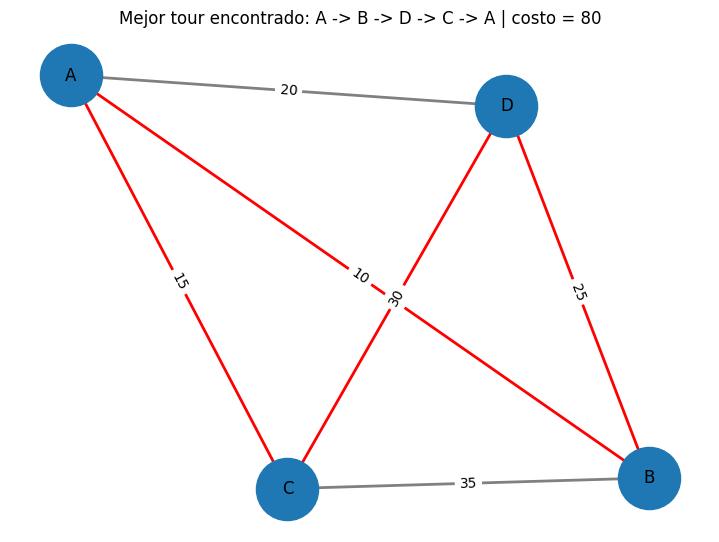

In [5]:
tour_edges = [(best_route[i], best_route[i + 1]) for i in range(len(best_route) - 1)]
edge_colors = ["red" if (u, v) in tour_edges or (v, u) in tour_edges else "gray" for u, v in G.edges()]

plt.figure(figsize=(7, 5))
nx.draw(G, pos, with_labels=True, node_size=2000, edge_color=edge_colors, width=2)
nx.draw_networkx_edge_labels(G, pos, edge_labels=weights)
plt.title(f"Mejor tour encontrado: {' -> '.join(best_route)} | costo = {best_cost}")
plt.axis("off")
plt.show()